<div align="center">
<img src="header.png" alt="Header">



### Mesh Bayesian Optimisation for Manifold-Constrained Optimisation of black-box functions.



[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1h9rlEkFjRTk6jsRR2c45x_l0VcsIYOyz?usp=sharing) [![GitHub](https://img.shields.io/badge/GitHub-repository-181717?logo=github)](https://github.com/aum3/Mesh-Manifold-Bayesian-Optimisation)





**Aum Dave** · University of Warwick



</div>



> **Outline** — I demonstrate an application Bayesian optimisation on meshes and how they can be used to optimise black-box functions which are constrained to only be defined on meshes. 



---
## 1. Introduction

> **How would you optimise a function when you don't know anything about it? You've no derivative, and even finding out its value at a point is expensive? :** *Bayesian optimisation is a framework that deals with this 'Black box' style optimisation in a way that is based on pure statistics and well-defined assumptions which are testable, meaning it is used across industry in high-risk and high-cost scenarios.*

### 1.1 Problem statement
The formal mathematical object is to find  

$$
x^\star = \arg\min_{x \in \mathcal{M}} f(x)
$$

*where $\mathcal{M}$ is a 2D manifold (surface) embedded in $\mathbb{R}^3$, and $f$ is an expensive, black-box function you want to optimise.*

### 1.2 The state of the art for this problem:
- There are closed-form methods for the kernel (the main ingredient for BO) on manifolds whose Laplace-Beltrami eigendecompositions are well-known ($S^n, T^n$ etc.)
- There are methods that break this mould and which can work on general manifolds by using approximations. For example, one could define a weighted graph that approximates a point cloud on a manifold.

### 1.3 Approach and contributions
My approach is to use a mesh as the approximation. The reasoning behind this is that there is a rich theory behind meshes and their usage for estimates regarding spectral operators (Mesh Laplacian, FEA etc.). Aside from this is general interest in meshes over graphs.

- We sample a 100-point point cloud in general from the manifold. We then fit a mesh to it using Poisson surface reconstruction due to the strong guarantees built in.
- We use the mesh kernel from the geometric_kernels package to give us a kernel.
- Since we have used an approximation of an approximation, I also test the veracity of the kernel against the true kernel using the synthetic example of a unit sphere.

### 1.4 How to read this notebook
There are utilities written in the mesh_bo_utils.py package. Each section below goes through the construction step by step.

---
## 2. Setup

In [1]:
%%capture
#@title Boilerplate

%pip install -q geometric_kernels pymanopt kagglehub

from pathlib import Path
from typing import NamedTuple
import urllib.request

UTILS_URL = "https://raw.githubusercontent.com/aum3/Mesh-Manifold-Bayesian-Optimisation/main/mesh_bo_utils.py"
if not Path("mesh_bo_utils.py").exists():
    urllib.request.urlretrieve(UTILS_URL, "mesh_bo_utils.py")

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
from geometric_kernels.kernels import MaternGeometricKernel
from geometric_kernels.spaces import Hypersphere, Mesh
from scipy.stats import norm

from mesh_bo_utils import (
    apply_plot_style, geodesic_distances, nearest_vertex_indices, plot_kernel_comparison,
    plot_kernel_influence, plot_objective, plot_posterior_evolution, plot_sample_path,
    read_ply_vertices, seed_everything,
)

%matplotlib inline

SEED = 0
rng = seed_everything(SEED)   # change SEED to get a different starting vertex
apply_plot_style()

---
## 3. Mesh and Kernel

**How can the value of f at a point affect your estimate for its value at other points**

For example, if you knew the heat at Coventry was 22C at a given time then how can you use this information elsewhere?

You may come upon the idea that you would "spread" the information around based on distance. For example, you would know all nearby towns and villages must be close to 22C. This is precisely how kernels work.

### The mesh
*A mesh is, essentially, a surface made out of triangles knitted together into a surface to try and hug the manifold. In our case I built my mesh by first inputting the 100-point point cloud and using Poisson surface reconstruction (PSR) on it. PSR takes these 100 points, assumes they lie on a single manifold surface and then fits a mesh to it using linear interpolation.*

<a title="Chrschn, Public domain, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Dolphin_triangle_mesh.png"><img width="330" alt="The polygon mesh of dolphin." src="https://thumb.wikimedia.org/wikipedia/commons/thumb/f/fb/Dolphin_triangle_mesh.png/330px-Dolphin_triangle_mesh.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail"></a>

### The Laplacian $\Delta$

<a title="Nicoguaro. Based on File:Heat eqn.gif by en:User:Oleg Alexandrov, CC BY 4.0 &lt;https://creativecommons.org/licenses/by/4.0&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Heat.gif"><img width="330" alt="Animation of the heat equation with a crescent moon as initial condition." src="https://thumb.wikimedia.org/wikipedia/commons/thumb/0/01/Heat.gif/330px-Heat.gif?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail"></a>

In Physics, heat spreads out in an "averaging" style of motion. When doing this averaging operation, when considering the pointwise behaviour we note that a point would lose heat if its hotter than the average heat of its immediate neighbours and it would gain it if it is colder. The laplacian measures the difference between the value of a function f at a point x and the average value of f at its neighbours. This difference gives us the rate at which the point changes temperature. This smoothing has the effect in that it "spreads" information and so our kernel is defined in this way (with minor difference to the real heat kernel).

(note we technically use the Laplace-Beltrami operator)

### The Matérn kernel

- **Lengthscale** $\ell$: *how far correlations reach across the surface*
- **Smoothness** $\nu$: *how rough or smooth the sampled functions are*

The Matérn kernel is useful to natural scientists since they lets you flexibly control the "roughness" of your data, making it realistic for messy real-world phenomena. This is because kernels dictate what kind of functions that are part of your distribution of functions in the GP. For example some physics functions may be continuous but not differentiable.

In [2]:
%%capture

data_dir = Path(kagglehub.dataset_download("aumdave3/obj-file"))
PLY_PATH = data_dir / "100 POINTS ONE.ply"

mesh = Mesh.load_mesh(str(PLY_PATH))
print("num_vertices:", mesh.num_vertices)

kernel = MaternGeometricKernel(mesh)

LENGTHSCALE, NU = 1.0, 0.5
params = kernel.init_params()
params["lengthscale"] = np.array([LENGTHSCALE])
params["nu"] = np.array([NU])

---
## 4. Objective Function

> **This is what we are trying to optimise** *It may be the temperature example used above or even other things such as the water-solubility of a molecules. Both of these examples are relevant in that they are both difficult and costly to find out for a given input*

Here we define it as f( (x,y,z)) = x just for the sake of exposition but this method could genuinely work for any continuous function (depending on kernel used)

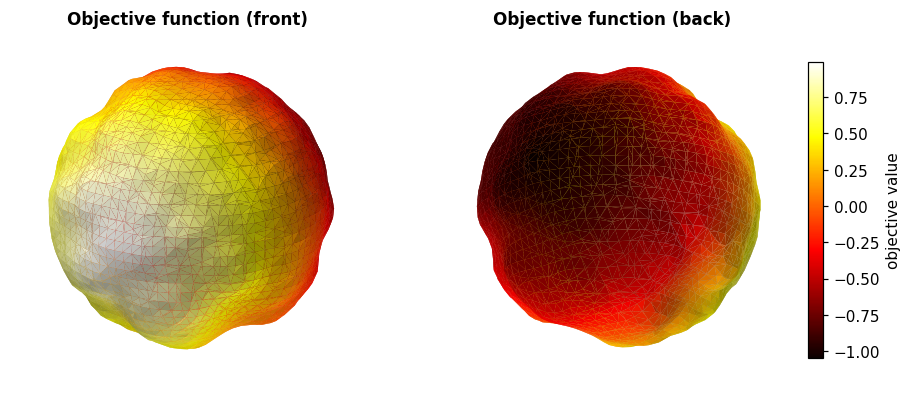

In [3]:
def f(idx):
    # objective = x-coordinate of the vertex. takes 0-based vertex indices
    return mesh.vertices[np.asarray(idx, dtype=np.int64).ravel(), 0]


objective_vals = f(np.arange(mesh.num_vertices))   # ground truth on every vertex

plot_objective(mesh, objective_vals)
plt.show()

### What you're looking at
This is simply the graph of f(x) over the mesh. Note that the mesh is not a perfect sphere, since it was built from only a 100 points on that sphere (i.e it had barely any information about the manifold it was considering). I built the mesh this way to illustrate that this method could be used even when the manifold is unknown / hypothesised, which is a common theme in the literature of computational Laplacian theory.

---
## 5. Bayesian Optimisation

> **Outline of method:** *Bayesian optimisation treats each point in the space as a random variable. The value at a point is a random variable which represents our model of the true function value f(x) at that point. We assume a Gaussian distribution at each point. The reasoning behind this is that we now have a distribution over possible functions that may line up with the real objective function.*

*The explanation for why this gives us a distribution is roughly: take a realisation of the Gaussian process, $f^*$, then $f^*(x)$ is known for all x $\in [0,1]$ for example. Consider $f^*(0)$ then $\forall ɛ \ \ k(0, ɛ)$ represents the covariance and thus $f^*(ɛ)$ is constrained.*

The set-up so far is what is called a Gaussian process. Once we have this Gaussian process we can now do Bayesian optimisation as follows:
- 0) We define a mean $\mu(x)$ and stdev $\sigma(x)$ function which outputs the mean and standard deviation of the random variable at any given point $x$
- 1) Take in some data $(x, f(x))$ by selecting x according to some rule dependent on
- 2) Since we have a Gaussian process, the value of f(x) at x affects our estimate for the random variable f(y) for all other y. We do this by updating the estimated mean $\mu(y)$ and stdev $\sigma(y)$ for all y. These are now called the posterior mean and stdev until the loop runs again. This relationship is detailed below.
- 3) Repeat. After each loop we keep track of all the data we have gathered and see what's the highest (or lowest) value of f we have found. We will then stop according to some rule. Note the only "proper information" is in this "observed data". This set is almost always tiny since adding to it (i.e gathering data) is costly by assumption. If f was cheap to evaluate then BO would not be used.

### 5.1 Gaussian-process surrogate
*The GP surrogate is our estimates for the mean and stdev at each point of the Gaussian process $\mu(x)$ and $\sigma(x)$. The surrogate is a cheap-to-evaluate function which is almost always differentiable. With a zero-mean prior and kernel $k$, conditioning on $m$ observations $(X, \mathbf{y})$ gives*

$$
\mu(\cdot) = k(\cdot, X)\,\big[K_{XX} + \sigma^2 I\big]^{-1}\mathbf{y},
\qquad
\Sigma(\cdot,\cdot') = k(\cdot,\cdot') - k(\cdot, X)\,\big[K_{XX} + \sigma^2 I\big]^{-1} k(X, \cdot').
$$

*(Here $\sigma^2$ is a jitter needed for numerical stability)*

### 5.2 Acquisition function: expected improvement
*The rule by which we find the next data point to sample from can be defined by optimising an acquisition function. The acquisition function essentially gives each point a "score". The BO process can essentially be seen as swapping the impossible and uncertain optimisation of the real objective function for optimising this acquisition function (easy to optimise since it is differentiable and cheap).*

*For minimisation with incumbent $f_{\min}$ and $Z = (f_{\min} - \mu - \xi)/\sigma$:*

$$
\mathrm{EI}(x) = (f_{\min} - \mu - \xi)\,\Phi(Z) + \sigma\,\varphi(Z)
$$

Note $\xi$ is a parameter which can allow us to set a preference between exploration and exploitation. This kind of easy, interpretable and intelligent design is why Bayesian optimisation is highly popular.

In [4]:
def expected_improvement(mean, std, f_best, xi=0.9):
    # EI for *minimisation*: how much below f_best (minus a margin xi) do we expect to land?
    mean, std = mean.reshape(-1, 1), std.reshape(-1, 1)
    gain = f_best - mean - xi
    with np.errstate(divide="ignore", invalid="ignore"):
        z = gain / std
    ei = gain * norm.cdf(z) + std * norm.pdf(z)
    return np.where(std > 1e-10, ei, 0.0)      # no uncertainty -> nothing to gain


class BOStep(NamedTuple):
    # snapshot after conditioning on the points in x_obs[:-1]. the last row of
    # x_obs / y_obs is the point EI picked next (and its objective value)
    mean: np.ndarray
    variance: np.ndarray
    ei: np.ndarray
    x_obs: np.ndarray
    y_obs: np.ndarray


def run_bo(n_iter, x_init, objective=f, xi=0.9, jitter=1e-6):
    n = mesh.num_vertices
    every_vertex = np.arange(n).reshape(-1, 1)

    K_prior = kernel.K(params, every_vertex, every_vertex)    # n x n, only computed once
    prior_var = np.diag(K_prior)
    prior_mean = np.zeros((n, 1))

    x_obs = np.asarray(x_init, dtype=np.int64).reshape(-1, 1)
    y_obs = objective(x_obs).reshape(-1, 1)

    history = []
    for _ in range(n_iter):
        idx = x_obs.ravel()
        K_xx = K_prior[np.ix_(idx, idx)] + jitter * np.eye(len(idx))
        K_xX = K_prior[idx]                                   # (m, n)

        # one solve covers both K_xx^-1 (y - m) and K_xx^-1 K_xX
        sol = np.linalg.solve(K_xx, np.hstack([y_obs - prior_mean[idx], K_xX]))
        mean = prior_mean + K_xX.T @ sol[:, :1]
        # only the diagonal of the posterior covariance is needed, so skip the n x n product
        variance = np.clip(prior_var - np.sum(K_xX * sol[:, 1:], axis=0), 0, None).reshape(-1, 1)

        ei = expected_improvement(mean, np.sqrt(variance), y_obs.min(), xi)

        x_next = int(np.argmax(ei))
        y_next = np.asarray(objective([x_next])).reshape(-1, 1)
        x_obs = np.vstack([x_obs, [[x_next]]])
        y_obs = np.vstack([y_obs, y_next])
        history.append(BOStep(mean, variance, ei, x_obs, y_obs))

    return history

---
## 6. Mesh BO in action: Posterior Evolution

> **The information spreads according to the geometry of the mesh**

### What you're looking at
- We are now performing Bayesian optimisation over a mesh.
- Note The colour represents our estimate for the mean at each point.
- The top row represents the front and the bottom represents the back of the mesh. The red diamond represents where the algorithm wants to search next (according to the acquisition function optimisation)

### What to notice
- The algorithm lucks finds a very solid minimum (optimum) on the second try yet stays nearby for the next 2 tries to "exploit"
- After fully exploiting that region, it then goes for a far away point, thus exploring.
- There are roughly 4k points on the mesh yet 5 are taken to get a solid understanding for the side of the mesh we are seeing as the "front"

> **The algorithm utilises the geometry to spread information and thus saves its own budget. It works intelligently by first exploiting then exploring.**

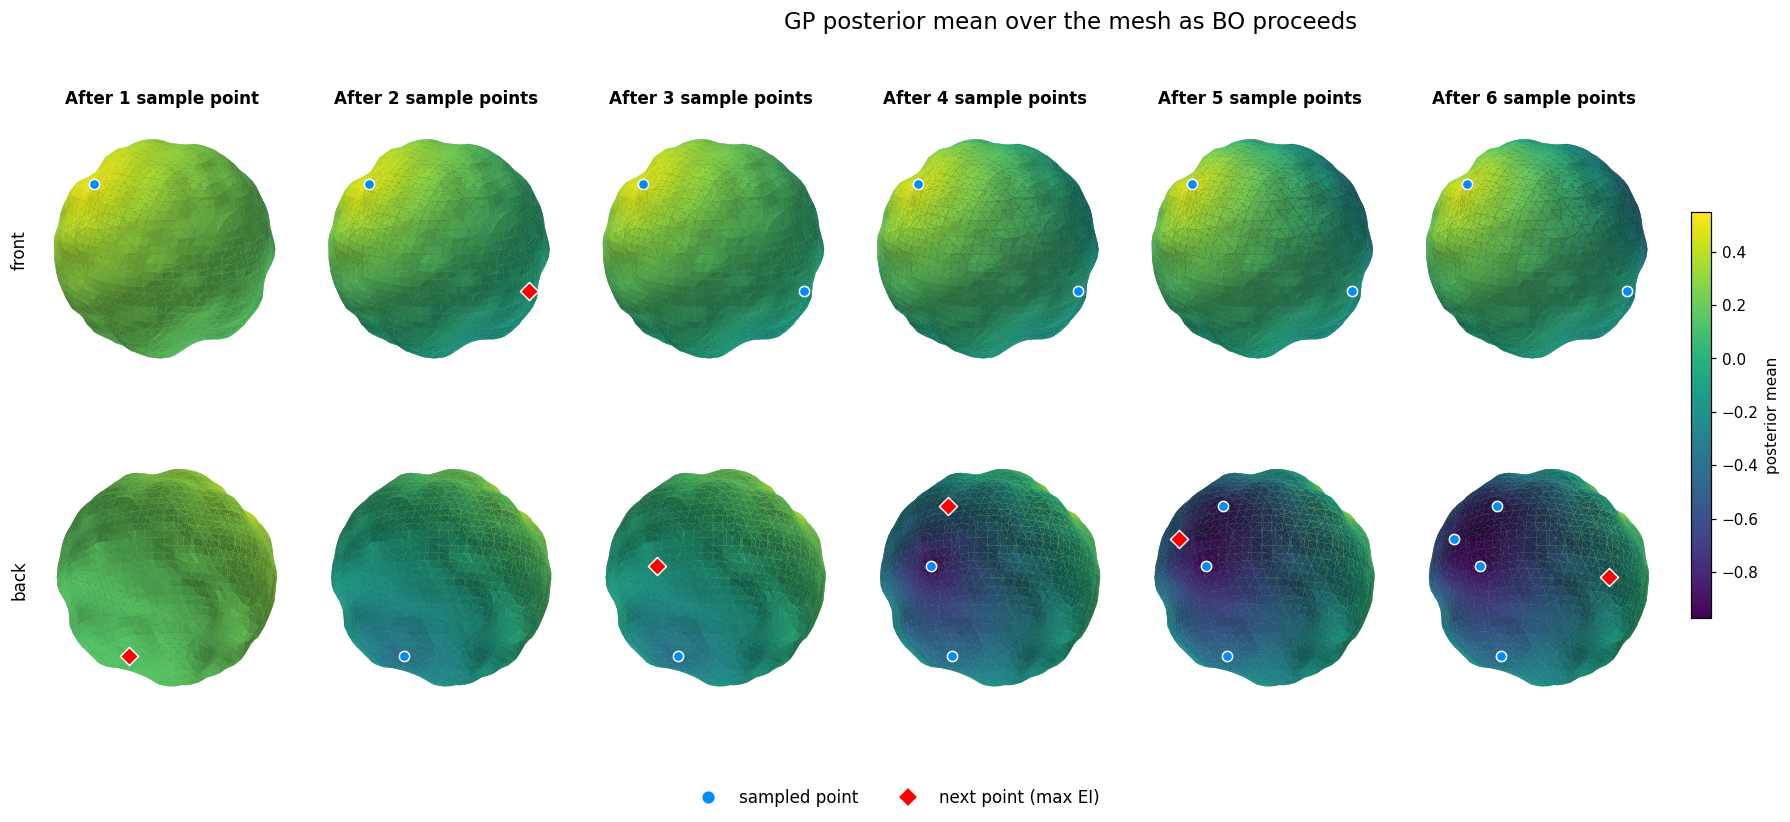

initial vertex value: 0.5475596189498901
sampled values (sorted, incl. initial): [-0.97176754 -0.91938204 -0.91281438 -0.47099268 -0.26728225  0.00433171
  0.54755962]
true minimum: -1.0502488613128662 at vertex 1976


In [5]:
initial_vertex = int(rng.integers(mesh.num_vertices))
NUM_STEPS = 6

history = run_bo(NUM_STEPS, x_init=[initial_vertex])

plot_posterior_evolution(mesh, history)
plt.show()

final = history[-1]
best = np.argmin(objective_vals)
print("initial vertex value:", objective_vals[initial_vertex])
print("sampled values (sorted, incl. initial):", np.sort(final.y_obs.ravel()))
print("true minimum:", objective_vals[best], "at vertex", best)

---
## 7. Sample Path

> **What path did the optimiser take?:** Note: this is a slightly different set-up.

### What you're looking at
The numbers give the order in which vertices were sampled, joined by curves that follow the surface. Left: ground-truth objective. Right: the surrogate's posterior mean after 3 sample points.

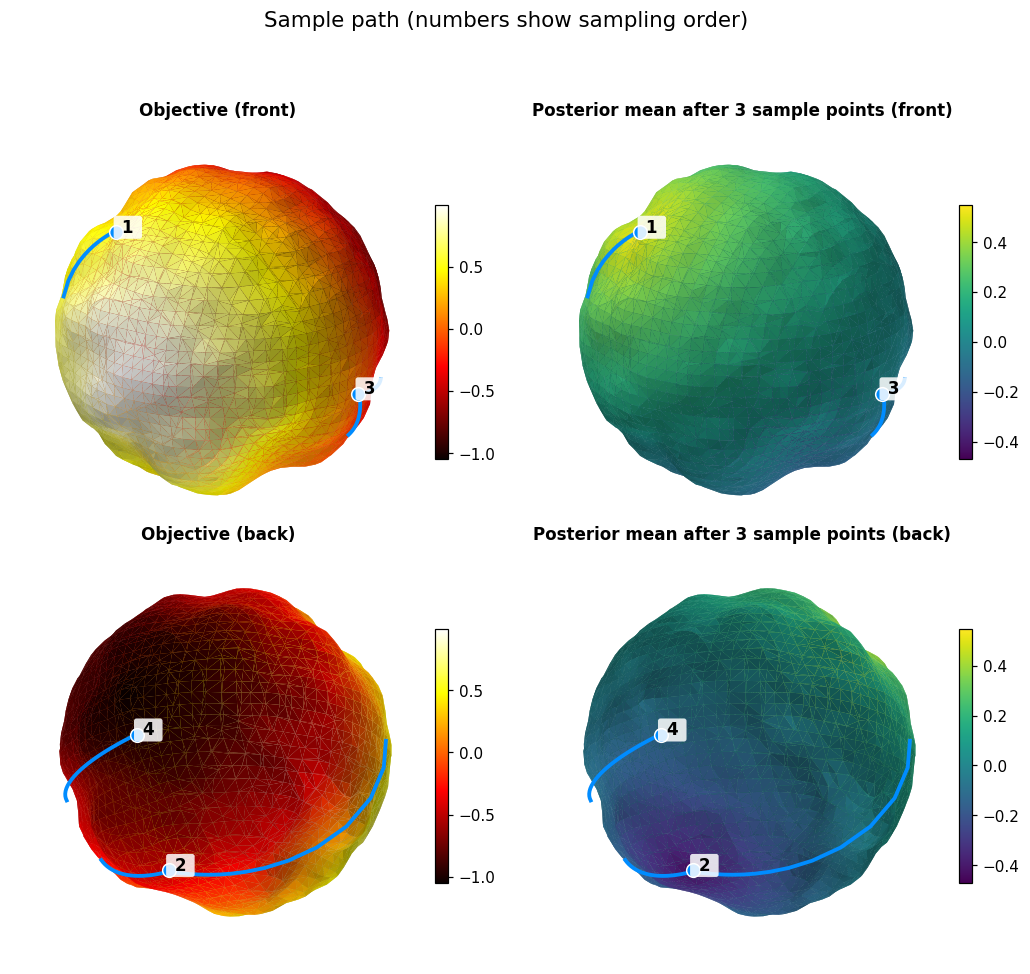

In [6]:
after_three = history[2]

plot_sample_path(mesh, objective_vals, after_three.mean, after_three.x_obs,
                 posterior_label="Posterior mean after 3 sample points")
plt.show()

---
## 8. Kernel Influence

> *What does one observation tell the model about the rest of the surface?*

### What you're looking at
*Heat-map of $k(x_0, \cdot)$ for a single source vertex $x_0$ (red diamond). Bright = strongly correlated with the source.*

### What it means
As we wanted in the beginning, the kernel gives us an adequate view of the geometry of the mesh by "averaging" out the information as if it was a heat source.

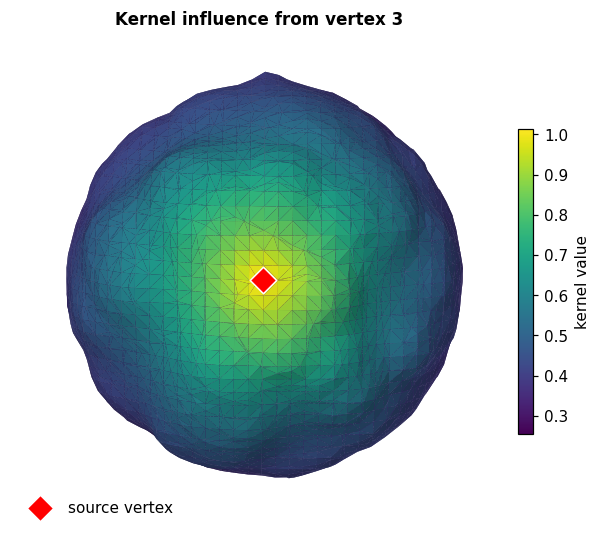

In [7]:
SOURCE_VERTEX = 3

plot_kernel_influence(mesh, kernel, params, SOURCE_VERTEX)
plt.show()

---
## 9. Error analysis

> How much do we lose by working on a mesh instead of the smooth manifold?

### Setup of the comparison
We take the same points, evaluate (a) the mesh kernel at their nearest mesh vertices and (b) the continuous Matérn kernel on the sphere $S^2$, and plot both against geodesic distance. Note: all the points were chosen from the sphere so that's why we can declare there is a "true" kernel.

### What you're looking at
mesh kernel. Blue: continuous sphere kernel. Each dot is a pair of points. Only a random subset of pairs is drawn to keep the plot readable.

In [8]:
ply_points = read_ply_vertices(PLY_PATH)                       # raw point cloud
sphere_points = ply_points / np.linalg.norm(ply_points, axis=1, keepdims=True)

# discretised kernel: snap each point to its nearest mesh vertex
vertex_ids = nearest_vertex_indices(sphere_points, mesh.vertices)
mesh_K = kernel.K(params, vertex_ids, vertex_ids)

# continuous kernel on S^2, same hyperparameters
sphere_kernel = MaternGeometricKernel(Hypersphere(dim=2))
sphere_K = sphere_kernel.K(params, sphere_points, sphere_points)

geo_dist = geodesic_distances(sphere_points)

print(f"RMS difference between the two kernels: {np.sqrt(np.mean((mesh_K - sphere_K) ** 2)):.4f}")

RMS difference between the two kernels: 0.0055


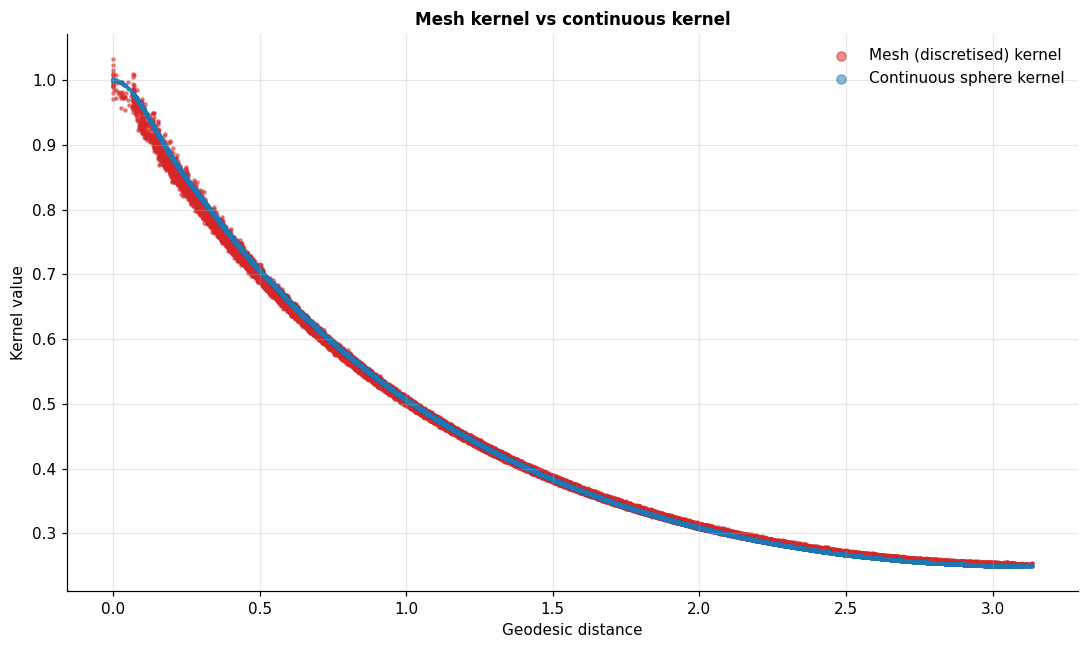

In [9]:
plot_kernel_comparison(geo_dist, mesh_K, sphere_K)
plt.show()

---
## 10. Conclusions and Future Work

Bayesian optimisation on meshes is a viable

### Summary of results
- The mesh kernel was very close to the continuous kernel
- Even despite the mesh itself being an approximation based on a 100 random points, the spectral fidelity was strong.

### Limitations
This was only tested on a single mesh and manifold. It is likely that manifolds with higher reach and other pathologies would be untenable with a mesh. Moreover, the mesh laplacian is a technique that is fraught with difficulties caused by the mesh quality.

---
## 11. References and Links

### References
1. ✏️ *Borovitskiy et al., "Matérn Gaussian processes on Riemannian manifolds", NeurIPS 2020.*

### Links
- 💻 **Code:** [GitHub repository](https://github.com/YOUR_USERNAME/YOUR_REPO)
- 🧑‍💻 **Author:** ✏️ *[LinkedIn](https://linkedin.com/in/aumd) · [Email](mailto:aumd39@gmail.com)*

### Acknowledgements
✏️ *Thank you to Dr. Zhengang Zhong for supervising me for this project and Warwick university for sponsoring the project.*